## Problem 4
Filippa Mudsam

**part b**

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf

In [8]:
rng = np.random.default_rng()
#writing out parameters
R = 2 * 10 ** 4
T = 10 ** 4
d0 = 10
# starting separation for all simulated lambs and lions
D = d0*np.ones(R, dtype = int)     
# boolean array tracking if lamb is alive, true bc they all start alive
alive = np.ones(R, dtype  =bool)   
#an array representing not being caught: will override with time caught later
capture_time = (T+1)*np.ones(R, dtype  =int)

In [9]:
for t in range(1, T+1):
    #start eith transition probabilities
    step = rng.choice([-2, 0, 2], size  =R, p = [.25, .5, .25])
    D = np.abs(D + step)

    #D==0 is where separation is 0
    just_caught = alive & (D == 0)
    #entering time of death in array
    capture_time[just_caught] = t
    #entering death into alive array
    alive[just_caught] = False

In [10]:
t_grid = np.arange(0, T+1)
#finding 'fraction of success' so how many lamb alive compared to total lambs
S1 = np.zeros(T+1)

for t in t_grid:
    S1[t] = np.mean(capture_time > t)

In [11]:
#correcting fit and slope
fit = (t_grid >= 10**2) & (t_grid <= 10**4)
slope, intercept = np.polyfit(np.log10(t_grid[fit]), np.log10(S1[fit]), 1)
beta1 = -slope

In [12]:
#continuum prediction
t_theory = t_grid[1:] # no division by 0
S1_theory = erf(d0/(2*np.sqrt(t_theory)))

### **part c** - set up

In [13]:
#set up parameters2
L = np.zeros(R, dtype = int)
H1 = d0 * np.ones(R, dtype = int)
H2 = d0 * np.ones(R, dtype = int)
alive2 = np.ones(R, dtype = bool)
capture_time2 = (T+1)*np.ones(R, dtype = int)

In [14]:
for t in range(1, T+1):
    lamb_step = rng.choice([-1,1], size = R)
    lion1_step = rng.choice([-1, 1], size = R)
    lion2_step = rng.choice([-1,1], size = R)

    L = L + lamb_step
    H1 += lion1_step
    H2 += lion2_step

    D1 = np.abs(H1-L)
    D2 = np.abs(H2-L)

    just_caught = alive2 & ((D1 ==0) | (D2 ==0))
    capture_time2[just_caught] = t
    alive2[just_caught] = False

In [15]:

S2 = np.zeros(T+1)
for t in t_grid:
    S2[t] = np.mean(capture_time2 > t)

In [16]:
slope2, intercept2 = np.polyfit(np.log10(t_grid[fit]), np.log10(S2[fit]), 1)
beta2 = -slope2
beta2

0.7634226567430961

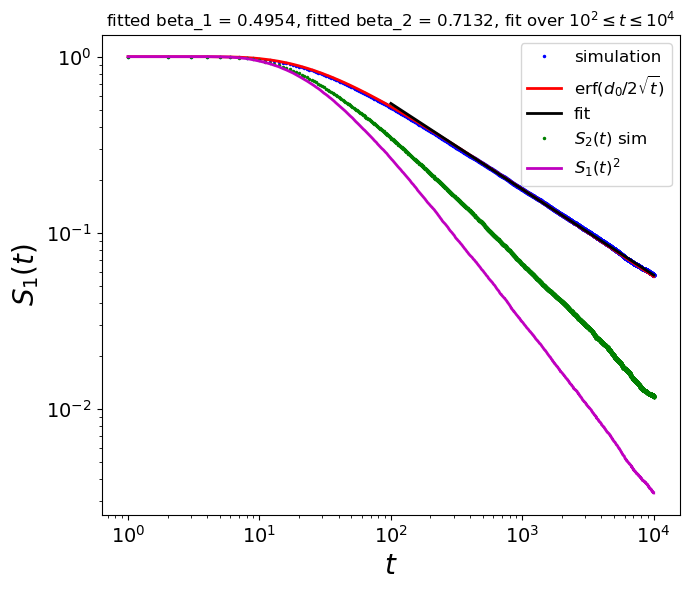

In [17]:
plt.figure(1, figsize=(7, 6))

#Start plotting! 
#S1[1:] because log inputs
plt.loglog(t_grid[1:], S1[1:], 'b.', markersize=3, label='simulation')
plt.loglog(t_theory, S1_theory, 'red', linewidth=2, label=r'erf($d_0/2\sqrt{t}$)')
plt.loglog(t_grid[fit], 10**intercept*t_grid[fit]**slope, 'black', linewidth=2,
           label='fit')

plt.loglog(t_grid[1:], S2[1:], 'g.', markersize=3, label='$S_2(t)$ sim')
plt.loglog(t_grid[1:], S1[1:]**2, 'm-', linewidth=2, label='$S_1(t)^2$')

plt.title(f'fitted beta_1 = 0.4954, fitted beta_2 = 0.7132, fit over $10^2 \leq t \leq 10^4$')
plt.xlabel('$t$', fontsize=20)
plt.ylabel('$S_1(t)$', fontsize=20)
plt.legend(fontsize=12)
plt.tick_params(labelsize=14)
plt.tight_layout()
plt.show()

In [18]:
print('beta1 =', beta1)


beta1 = 0.4876647368948556


Tabulate S2 and S12 at t = 102,103,104

In [19]:
print(f"{'t':>8}  {'S2(t)':>10}  {'S1(t)^2':>10}")
for tt in [10**2, 10**3, 10**4]:
    print(f"{tt:>8}  {S2[tt]:>10.5f}  {S1[tt]**2:>10.5f}")

       t       S2(t)     S1(t)^2
     100     0.34525     0.26399
    1000     0.06630     0.03113
   10000     0.01170     0.00332
